#Klasifikasi untuk Keputusan Kategorikal pada Data Teknik Industri

Sesi ini membahas penerapan machine learning terawasi untuk masalah prediksi kategorikal melalui pendekatan klasifikasi. Dalam konteks data science, klasifikasi digunakan ketika variabel target berbentuk kategori, misalnya: defect/tidak defect, tepat waktu/terlambat, lolos/gagal inspeksi, atau mesin normal/mesin rusak.

Notebook ini dirancang untuk memperkenalkan alur kerja klasifikasi secara sistematis: memahami variabel target kategorikal, memilih fitur, membagi data latih dan data uji, melatih model klasifikasi sederhana, melakukan prediksi kategori, dan mengevaluasi performa model menggunakan metrik akurasi, presisi, recall, dan confusion matrix.

## 1. Landasan Konseptual: Apa Itu Klasifikasi?

Klasifikasi merupakan metode supervised learning yang digunakan ketika target yang ingin diprediksi berupa kategori atau kelas. Model klasifikasi mempelajari pola hubungan antara variabel input (fitur) dengan variabel output kategorikal, kemudian menggunakan pola tersebut untuk mengklasifikasikan observasi baru ke dalam salah satu kategori yang ada.

Dalam konteks teknik industri, klasifikasi sangat relevan untuk:
- Prediksi defect (defect/tidak defect),
- Prediksi keterlambatan (terlambat/tepat waktu),
- Klasifikasi kualitas (lolos/gagal),
- Prediksi status mesin (rusak/normal),
- Keputusan penerimaan batch (terima/kembalikan).

Model klasifikasi biner (dua kelas) menjadi titik awal yang tepat karena konsepnya lebih mudah dipahami sebelum melanjutkan ke klasifikasi multi-kelas.

## 2. Capaian Pembelajaran Sesi

Setelah menyelesaikan sesi ini, mahasiswa diharapkan mampu:
1. Menjelaskan perbedaan masalah regresi dan klasifikasi.
2. Menentukan variabel target dan fitur input untuk model klasifikasi.
3. Melakukan encoding pada variabel target kategorikal.
4. Melatih model klasifikasi menggunakan logistic regression dan decision tree.
5. Menginterpretasikan confusion matrix, accuracy, precision, dan recall.
6. Menjelaskan hasil model dalam konteks operasional teknik industri.

## 3. Deskripsi Dataset dan Penentuan Masalah

Dataset merepresentasikan data produksi per shift dengan beberapa variabel operasional. Pada sesi ini, variabel **Bad_Quality** akan digunakan sebagai target prediksi kategorikal.

Variabel Bad_Quality bernilai "Ya" jika shift tersebut mengalami kualitas buruk (defect tinggi atau output rendah secara relatif), dan "Tidak" jika kualitas baik. Target ini cocok untuk masalah klasifikasi biner.

In [ ]:
# [CODEBLOCK]
# =============================================================================
# IMPOR LIBRARY YANG DIPERLUKAN
# =============================================================================
# pandas: manipulasi data
# matplotlib: visualisasi
# train_test_split: membagi data latih dan data uji
# LogisticRegression: model klasifikasi logistic regression
# DecisionTreeClassifier: model klasifikasi decision tree
# LabelEncoder: encoding target kategorikal
# confusion_matrix, accuracy_score, precision_score, recall_score: evaluasi model

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

print('Library untuk klasifikasi siap digunakan')

Library untuk klasifikasi siap digunakan


In [ ]:
# =============================================================================
# MEMBUAT DATAFRAME DARI VARIABEL PYTHON
# =============================================================================
# Data didefinisikan langsung agar mahasiswa dapat memodifikasi nilai
# tanpa perlu mengakses file eksternal.

data = {
    'Tanggal': [
        '2026-01-05','2026-01-05','2026-01-06','2026-01-06',
        '2026-01-07','2026-01-07','2026-01-08','2026-01-08',
        '2026-01-09','2026-01-09','2026-01-10','2026-01-10',
        '2026-01-11','2026-01-11','2026-01-12','2026-01-12',
        '2026-01-13','2026-01-13','2026-01-14','2026-01-14'
    ],
    'Shift': [
        'Pagi','Siang','Pagi','Siang',
        'Pagi','Siang','Pagi','Siang',
        'Pagi','Siang','Pagi','Siang',
        'Pagi','Siang','Pagi','Siang',
        'Pagi','Siang','Pagi','Siang'
    ],
    'Mesin': [
        'M1','M1','M1','M1',
        'M2','M2','M2','M2',
        'M1','M1','M2','M2',
        'M1','M1','M2','M2',
        'M1','M1','M2','M2'
    ],
    'Downtime_Menit': [
        30,35,25,28,40,42,20,22,15,18,24,26,33,36,19,21,45,48,27,30
    ],
    'Defect_Unit': [
        5,6,4,5,6,7,3,4,2,3,4,4,5,6,3,3,8,9,5,6
    ],
    'Output_Unit': [
        120,118,135,132,128,125,140,138,150,146,142,139,131,129,147,145,110,105,133,130
    ],
    'Suhu_Mesin': [
        72,74,70,71,79,81,69,70,67,68,73,75,76,77,68,69,82,84,71,73
    ],
    'Operator_Hadir': [
        8,8,8,8,7,7,8,8,8,8,7,7,8,8,8,8,7,7,8,8
    ],
    'Target_Unit': [
        130,130,130,130,130,130,135,135,140,140,138,138,132,132,140,140,125,125,135,135
    ],
    'Bad_Quality': [
        'Tidak','Tidak','Tidak','Tidak',
        'Ya','Ya','Tidak','Tidak',
        'Tidak','Tidak','Tidak','Tidak',
        'Tidak','Tidak','Tidak','Tidak',
        'Ya','Ya','Tidak','Tidak'
    ]
}

df = pd.DataFrame(data)
df.head()

,Tanggal,Shift,Mesin,Downtime_Menit,Defect_Unit,Output_Unit,Suhu_Mesin,Operator_Hadir,Target_Unit,Bad_Quality
0,2026-01-05,Pagi,M1,30,5,120,72,8,130,Tidak
1,2026-01-05,Siang,M1,35,6,118,74,8,130,Tidak
2,2026-01-06,Pagi,M1,25,4,135,70,8,130,Tidak
3,2026-01-06,Siang,M1,28,5,132,71,8,130,Tidak
4,2026-01-07,Pagi,M2,40,6,128,79,7,130,Ya


## 4. Menentukan Fitur dan Target Klasifikasi

Dalam klasifikasi, variabel target adalah kategori yang ingin diprediksi. Pada sesi ini:

- **Target**: `Bad_Quality` (Ya/Tidak)
- **Fitur**: `Downtime_Menit`, `Defect_Unit`, `Output_Unit`, `Suhu_Mesin`, `Operator_Hadir`, `Target_Unit`

Pemilihan fitur didasarkan pada relevansi operasional terhadap kualitas produksi.

In [ ]:
# =============================================================================
# ENCODING VARIABEL TARGET KATEGORIKAL
# =============================================================================
# LabelEncoder mengubah kategori teks menjadi angka
# Tidak/Ya secara otomatis diubah menjadi 0/1
# Model machine learning membutuhkan input numerik

le = LabelEncoder()
df['Bad_Quality_Encoded'] = le.fit_transform(df['Bad_Quality'])

# Menampilkan hasil encoding
df[['Bad_Quality', 'Bad_Quality_Encoded']].head()

,Bad_Quality,Bad_Quality_Encoded
0,Tidak,0
1,Tidak,0
2,Tidak,0
3,Tidak,0
4,Ya,1


In [ ]:
# =============================================================================
# MEMISAHKAN FITUR (X) DAN TARGET (y)
# =============================================================================
# X berisi variabel input yang akan digunakan model
# y berisi variabel target kategorikal yang sudah di-encode

X = df[['Downtime_Menit', 'Defect_Unit', 'Output_Unit', 'Suhu_Mesin', 'Operator_Hadir', 'Target_Unit']]
y = df['Bad_Quality_Encoded']

print('Bentuk data fitur:', X.shape)
print('Bentuk data target:', y.shape)
print('Kategori target:', le.classes_)

Bentuk data fitur: (20, 6)
Bentuk data target: (20,)
Kategori target: ['Tidak' 'Ya']


## 5. Train-Test Split untuk Klasifikasi

Pembagian data menjadi data latih dan data uji juga penting dalam klasifikasi. Tujuan yang sama: mengevaluasi model pada data yang tidak digunakan saat pelatihan.

In [ ]:
# =============================================================================
# MEMBAGI DATA MENJADI TRAINING SET DAN TESTING SET
# =============================================================================
# test_size=0.25 berarti 25% data digunakan untuk pengujian
# random_state=42 digunakan agar hasil pembagian konsisten

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

print('Jumlah data latih:', X_train.shape[0])
print('Jumlah data uji:', X_test.shape[0])

Jumlah data latih: 15
Jumlah data uji: 5


In [ ]:
# =============================================================================
# MEMBANGUN DAN MELATIH MODEL LOGISTIC REGRESSION
# =============================================================================
# LogisticRegression() membuat objek model klasifikasi
# fit() melatih model menggunakan data latih

model_lr = LogisticRegression()
model_lr.fit(X_train, y_train)

print('Logistic regression berhasil dilatih')

Logistic regression berhasil dilatih


## 7. Membangun Model Decision Tree

Decision tree adalah model klasifikasi yang menggunakan struktur pohon keputusan. Model ini cenderung lebih mudah diinterpretasikan karena proses keputusannya dapat divisualisasikan.

In [ ]:
# =============================================================================
# MEMBANGUN DAN MELATIH MODEL DECISION TREE
# =============================================================================
# DecisionTreeClassifier() membuat model klasifikasi berbasis pohon

model_dt = DecisionTreeClassifier(max_depth=3, random_state=42)
model_dt.fit(X_train, y_train)

print('Decision tree berhasil dilatih')

Decision tree berhasil dilatih


## 8. Melakukan Prediksi dan Evaluasi Model

Setelah model dilatih, langkah berikutnya adalah menghasilkan prediksi pada data uji. Prediksi kemudian dibandingkan dengan nilai aktual untuk menilai performa model.

In [ ]:
# =============================================================================
# MENGHASILKAN PREDIKSI UNTUK KEDUA MODEL
# =============================================================================
# predict() menghasilkan prediksi kategori (bukan probabilitas)

y_pred_lr = model_lr.predict(X_test)
y_pred_dt = model_dt.predict(X_test)

print('Prediksi Logistic Regression:', y_pred_lr)
print('Prediksi Decision Tree:', y_pred_dt)

Prediksi Logistic Regression: [0 1 0 0 0]
Prediksi Decision Tree: [0 1 0 0 0]


In [ ]:
# =============================================================================
# MENGHITUNG METRIK EVALUASI UNTUK LOGISTIC REGRESSION
# =============================================================================
# accuracy_score: proporsi prediksi yang benar
# precision_score: dari yang diprediksi positif, berapa yang benar positif
# recall_score: dari yang sebenarnya positif, berapa yang berhasil diprediksi

accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)

print('==== Logistic Regression ====')
print('Accuracy:', accuracy_lr)
print('Precision:', precision_lr)
print('Recall:', recall_lr)

==== Logistic Regression ====
Accuracy: 1.0
Precision: 1.0
Recall: 1.0


In [ ]:
# =============================================================================
# MENGHITUNG METRIK EVALUASI UNTUK DECISION TREE
# =============================================================================

accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)

print('==== Decision Tree ====')
print('Accuracy:', accuracy_dt)
print('Precision:', precision_dt)
print('Recall:', recall_dt)

==== Decision Tree ====
Accuracy: 1.0
Precision: 1.0
Recall: 1.0


## 9. Interpretasi Metrik Evaluasi Klasifikasi

Penting untuk memahami makna setiap metrik:

- **Accuracy**: proporsi total prediksi yang benar (benar positif + benar negatif) / total data.
- **Precision**: dari semua yang diprediksi sebagai "Ya" (positif), berapa persen yang benar-benar "Ya". Penting ketika biaya false positif tinggi.
- **Recall**: dari semua yang sebenarnya "Ya", berapa persen yang berhasil terdeteksi. Penting ketika biaya false negative tinggi.

Dalam konteks industri, misalnya saat mendeteksi defect:
- Presisi tinggi berarti saat model bilang "defect", kemungkinan besar benar defect.
- Recall tinggi berarti sebagian besar defect berhasil terdeteksi, tidak banyak yang lolos.

In [ ]:
# =============================================================================
# CONTOH INTERPRETASI OPERASIONAL
# =============================================================================
#Dalam kasus defect:
# - Precision tinggi = rendah false positive (tidak banyak batch bagus yang salah dikira defect)
# - Recall tinggi = rendah false negative (sedikit defect yang lolos dan tidak terdeteksi)

print('Jika tujuan utama adalah meminimalkan defect yang lolos, fokus pada Recall.')
print('Jika tujuan utama adalah menghindari pembuangan batch yang sebenarnya bagus, fokus pada Precision.')

Jika tujuan utama adalah meminimalkan defect yang lolos, fokus pada Recall.
Jika tujuan utama adalah menghindari pembuangan batch yang sebenarnya bagus, fokus pada Precision.


## 10. Confusion Matrix untuk Visualisasi Kesalahan

Confusion matrix adalah tabel 2×2 yang menunjukkan distribusi prediksi vs aktual. Tabel ini sangat membantu untuk memahami jenis kesalahan model.

Confusion Matrix Logistic Regression:
[[4 0]
 [0 1]]


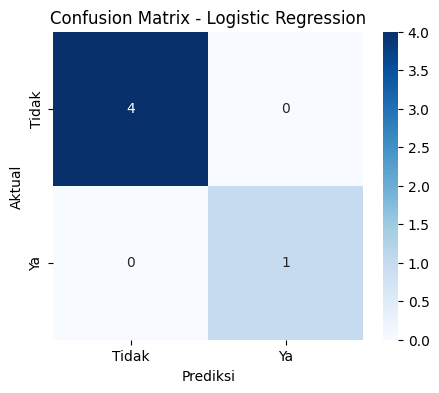

In [ ]:
# =============================================================================
# CONFUSION MATRIX UNTUK LOGISTIC REGRESSION
# =============================================================================
# Tuple: (True Negative, False Positive, False Negative, True Positive)

cm_lr = confusion_matrix(y_test, y_pred_lr)
print('Confusion Matrix Logistic Regression:')
print(cm_lr)

# Visualisasi confusion matrix dengan heatmap
plt.figure(figsize=(5,4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Tidak','Ya'], yticklabels=['Tidak','Ya'])
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

Confusion Matrix Decision Tree:
[[4 0]
 [0 1]]


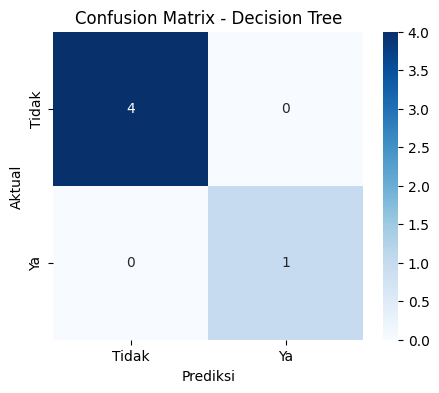

In [ ]:
# =============================================================================
# CONFUSION MATRIX UNTUK DECISION TREE
# =============================================================================

cm_dt = confusion_matrix(y_test, y_pred_dt)
print('Confusion Matrix Decision Tree:')
print(cm_dt)

plt.figure(figsize=(5,4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Tidak','Ya'], yticklabels=['Tidak','Ya'])
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix - Decision Tree')
plt.show()

## 11. Penjelasan Confusion Matrix

Confusion matrix terdiri dari:
- **True Negative (TN)**: aktual "Tidak", diprediksi "Tidak" (benar).
- **False Positive (FP)**: aktual "Tidak", diprediksi "Ya" (salah, false alarm).
- **False Negative (FN)**: aktual "Ya", diprediksi "Tidak" (salah, terlewat).
- **True Positive (TP)**: aktual "Ya", diprediksi "Ya" (benar).



In [ ]:
# =============================================================================
# MEMBANDINGKAN KEDUA MODEL
# =============================================================================

comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree'],
    'Accuracy': [accuracy_lr, accuracy_dt],
    'Precision': [precision_lr, precision_dt],
    'Recall': [recall_lr, recall_dt]
})

comparison

,Model,Accuracy,Precision,Recall
0,Logistic Regression,1.0,1.0,1.0
1,Decision Tree,1.0,1.0,1.0


## 14. Evaluasi Formatif

Jawab singkat:
1. Apa perbedaan utama antara regresi dan klasifikasi?
2. Mengapa variabel target kategorikal perlu di-encode?
3. Apa arti precision dalam konteks defect detection?
4. Apa arti recall dalam konteks defect detection?
5. Mengapa confusion matrix penting untuk evaluasi model klasifikasi?